In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect("inventory.db")


# Loading The Dataset.

In [3]:
df = pd.read_sql("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,description,PurchasePrice,volume,ActualPrice,Total_Qt,Total_Purchase,TotalSalesQt,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,Freight_Cost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,22.99,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,29.99,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [4]:
#  Summary Statistics
df.describe()

,VendorNumber,Brand,PurchasePrice,volume,ActualPrice,Total_Qt,Total_Purchase,TotalSalesQt,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,Freight_Cost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio
count,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,1.069200e+04,1.069200e+04,10692.000000,10692.000000
mean,10650.649458,18039.228769,24.385303,847.360550,35.643671,3140.886831,3.010669e+04,3077.482136,4.223907e+04,18793.783627,1774.226259,61433.763214,1.213238e+04,-inf,1.706793,2.504390
std,18753.519148,12662.187074,109.269375,664.309212,148.246016,11095.086769,1.230678e+05,10952.851391,1.676553e+05,44952.773386,10975.582240,60938.458032,4.622434e+04,NaN,6.020460,8.459067
min,2.000000,58.000000,0.360000,50.000000,0.490000,1.000000,7.100000e-01,0.000000,0.000000e+00,0.000000,0.000000,0.090000,-5.200278e+04,-inf,0.000000,0.000000
25%,3951.000000,5793.500000,6.840000,750.000000,10.990000,36.000000,4.534575e+02,33.000000,7.292200e+02,289.710000,4.800000,14069.870000,5.292000e+01,1.332451e+01,0.807229,1.153729
50%,7153.000000,18761.500000,10.455000,750.000000,15.990000,262.000000,3.655465e+03,261.000000,5.298045e+03,2857.800000,46.570000,50293.620000,1.399640e+03,3.040546e+01,0.981529,1.436894
75%,9552.000000,25514.250000,19.482500,750.000000,28.990000,1975.750000,2.073825e+04,1929.250000,2.839692e+04,16059.562500,418.650000,79528.990000,8.660200e+03,3.995613e+01,1.039342,1.665449
max,201359.000000,90631.000000,5681.810000,20000.000000,7499.990000,337660.000000,3.811252e+06,334939.000000,5.101920e+06,672819.310000,368242.800000,257032.070000,1.290668e+06,9.971666e+01,274.500000,352.928571


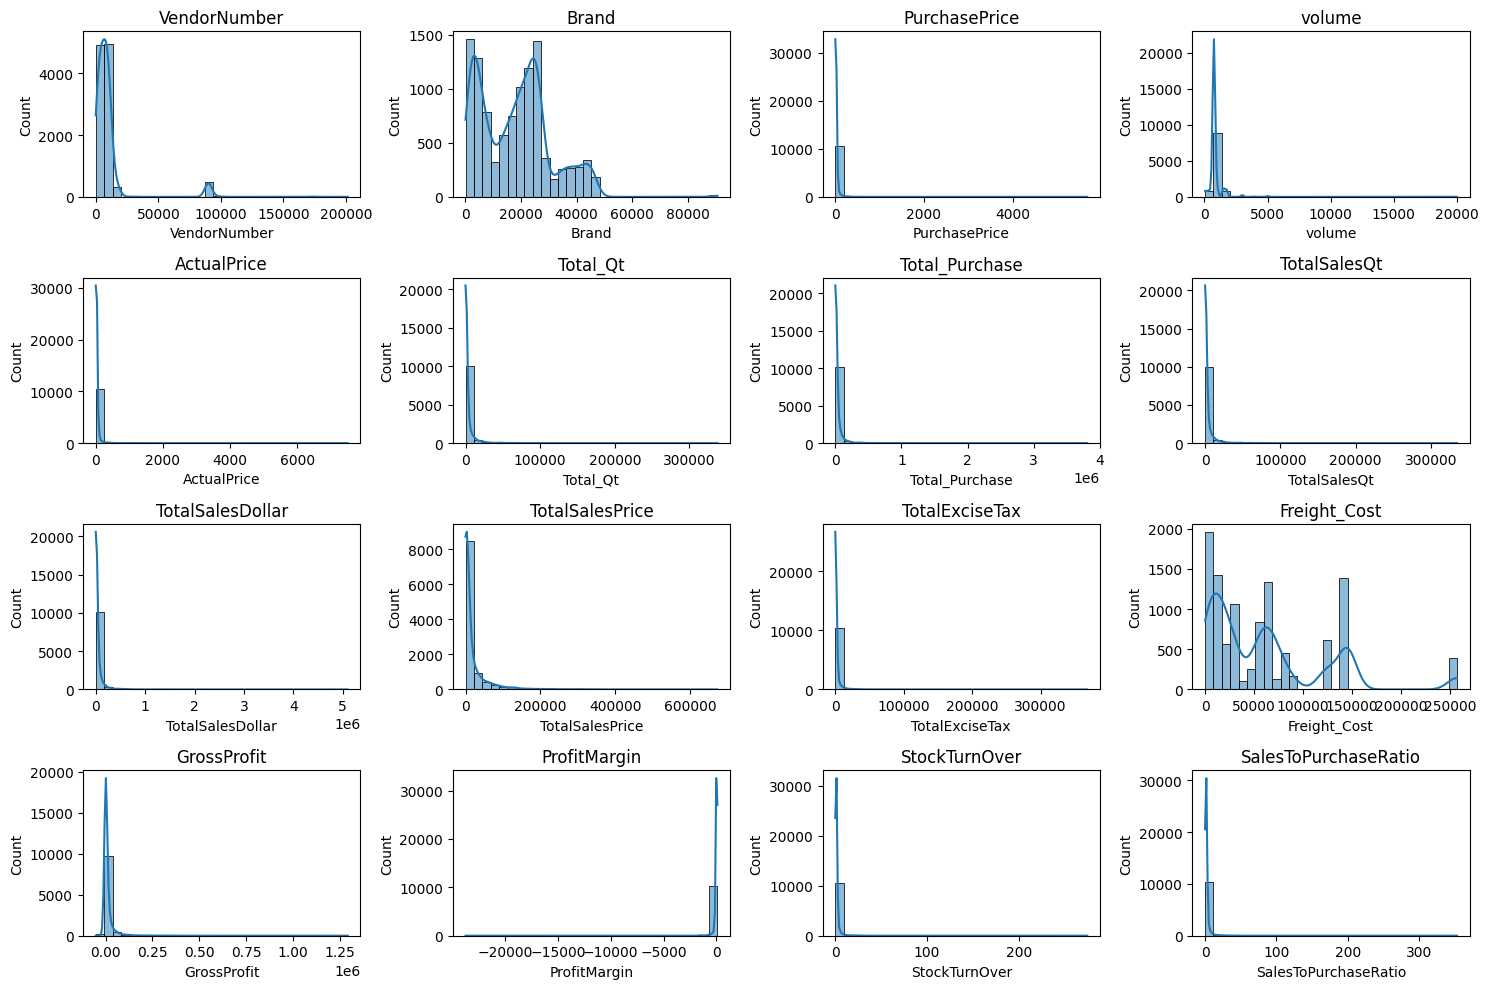

In [5]:
# Distribution Plots For Numerical Columns
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

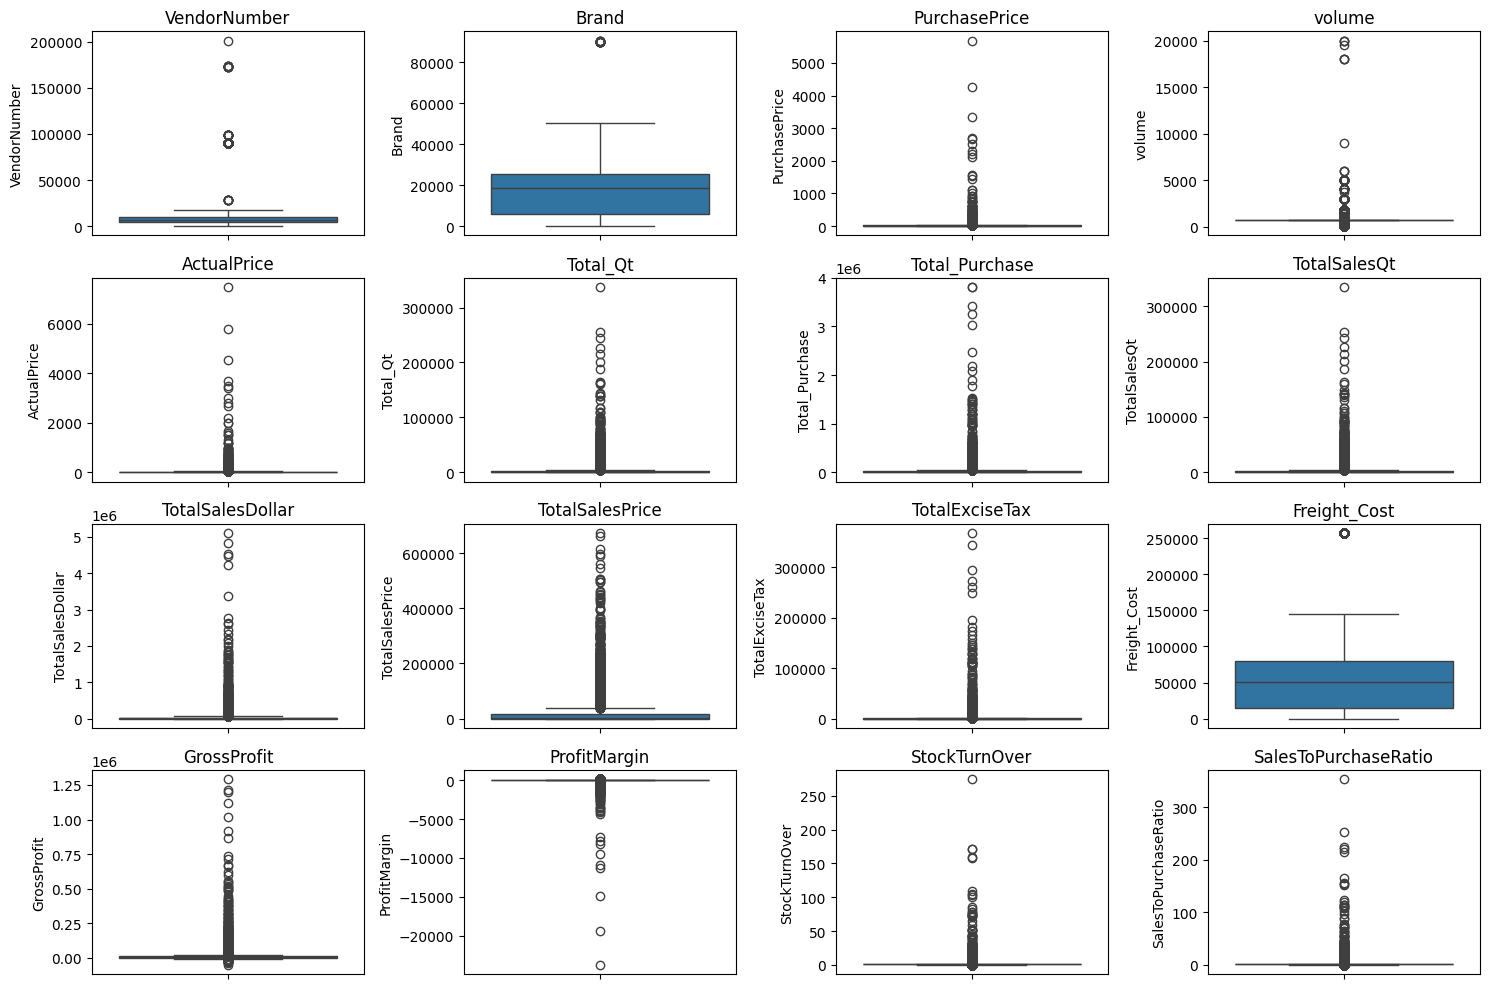

In [6]:
# Detection Of Outliers Using Box Plot.
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights.

Negative & Zero Values:

• Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
• Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
• Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers Indicated by High Standard Deviations:

• Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
• Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
• Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [7]:
# Removing inconsistent and -ve values
df = pd.read_sql("""select * from vendor_sales_summary
                 where GrossProfit>0 AND
                 ProfitMargin>0 AND 
                 TotalSalesQt>0""",conn)
df

,VendorNumber,VendorName,Brand,description,PurchasePrice,volume,ActualPrice,Total_Qt,Total_Purchase,TotalSalesQt,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,Freight_Cost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,22.99,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,29.99,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,750.0,4.99,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,50.0,0.49,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,50.0,0.99,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,200.0,1.99,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


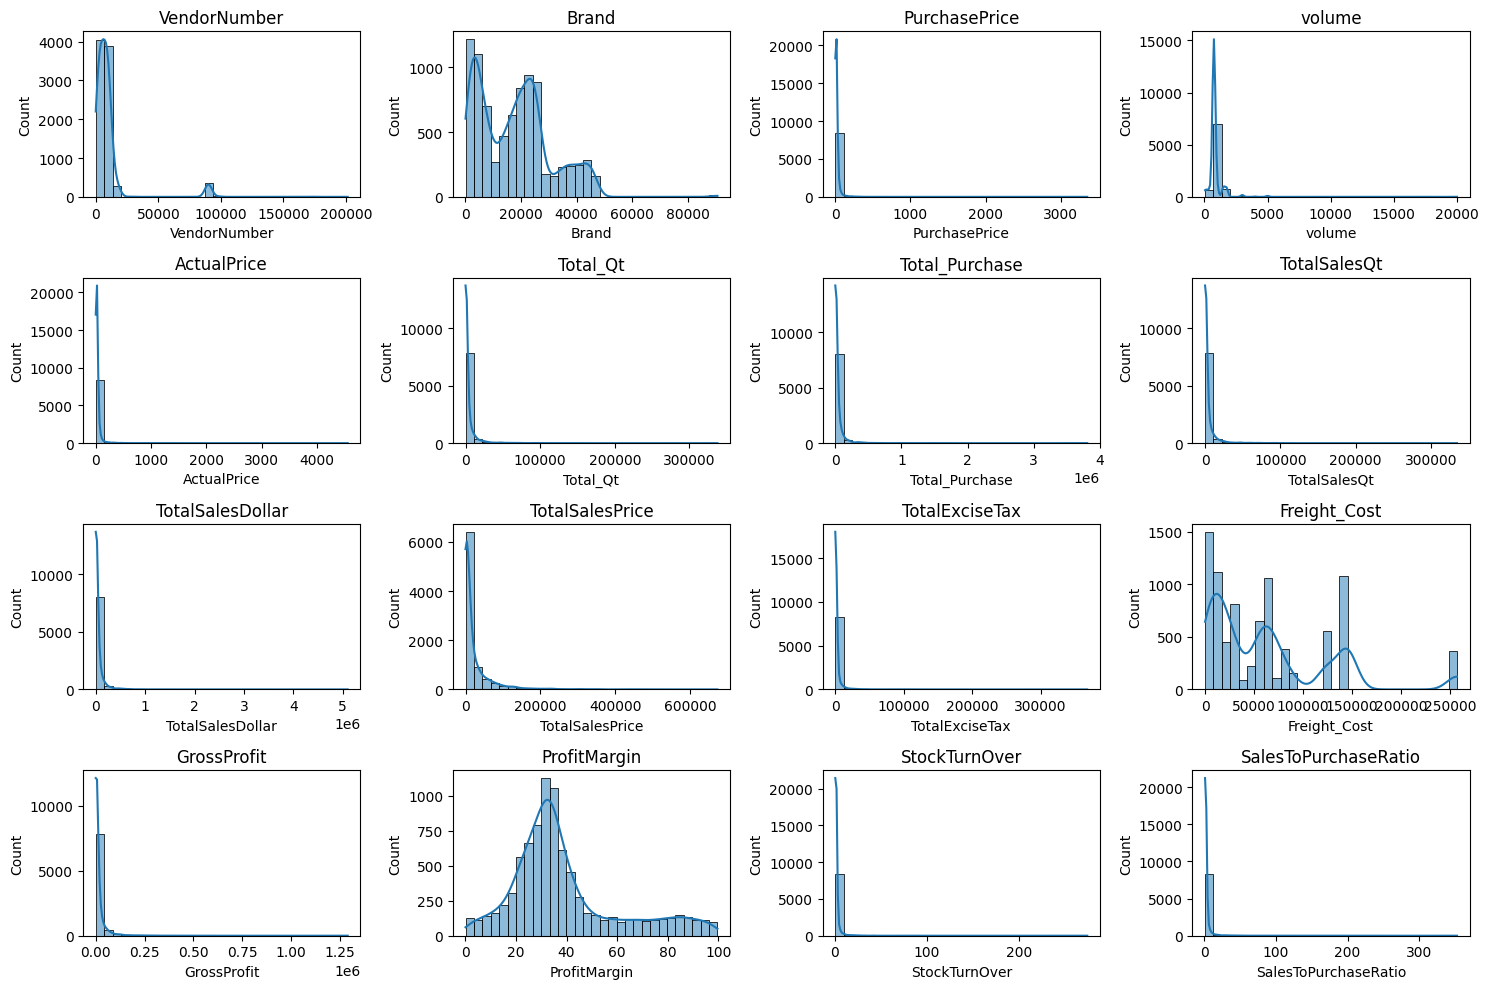

In [8]:
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

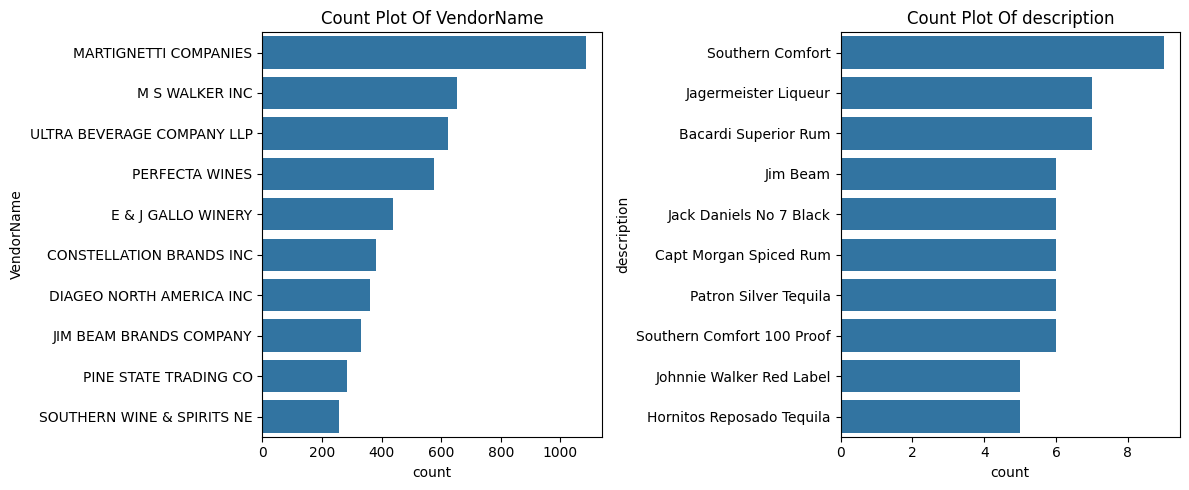

In [9]:
categorical_cols = ["VendorName","description"]
plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) # Top 10 Categories
    plt.title(f'Count Plot Of {col}')
plt.tight_layout()
plt.show()

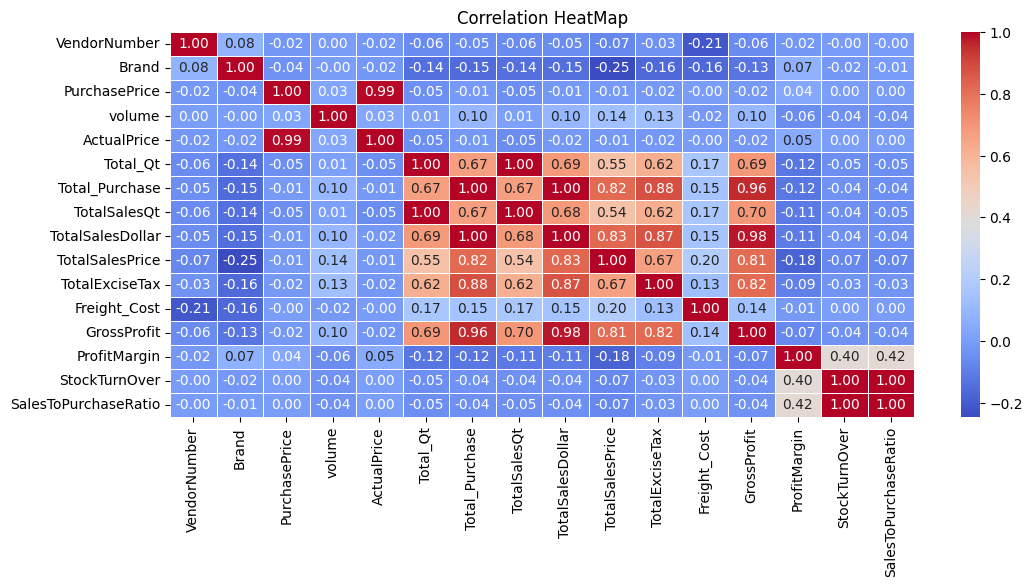

In [10]:
# Correlation HeatMap
plt.figure(figsize=(12,5))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation HeatMap")
plt.show()

## Correlation Insights.
- PurchasePrice has weak correlations with TotalSales Dollars (-0.012) and Gross Profit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- Stock Turnover has weak negative correlations with both Gross Profit (-0.038) and Profit Margin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis

 Identify Brands That Needs Promotional or Pricing Adjustments Which Exhibit Lower Sales Performance but higher profit margins.

In [11]:
brand_perf = df.groupby("description").agg({"TotalSalesDollar":"sum","ProfitMargin":"mean"}).reset_index()

In [12]:
low_sales_threshold = brand_perf['TotalSalesDollar'].quantile(0.15)  # Lowest Should be less than 15% 
high_sales_threshold = brand_perf['ProfitMargin'].quantile(0.85)  # Highest Should be more than 85% 

In [13]:
low_sales_threshold

np.float64(560.299)

In [14]:
high_sales_threshold

np.float64(64.97017552750113)

In [15]:
target_brands = brand_perf[
     (brand_perf["TotalSalesDollar"] <= low_sales_threshold)&
    (brand_perf["ProfitMargin"] >= high_sales_threshold)
]
print("Brand with low sales and high profit margin")
display(target_brands.sort_values('TotalSalesDollar'))

Brand with low sales and high profit margin


,description,TotalSalesDollar,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [16]:
brand_perf = brand_perf[brand_perf['TotalSalesDollar']<10000]

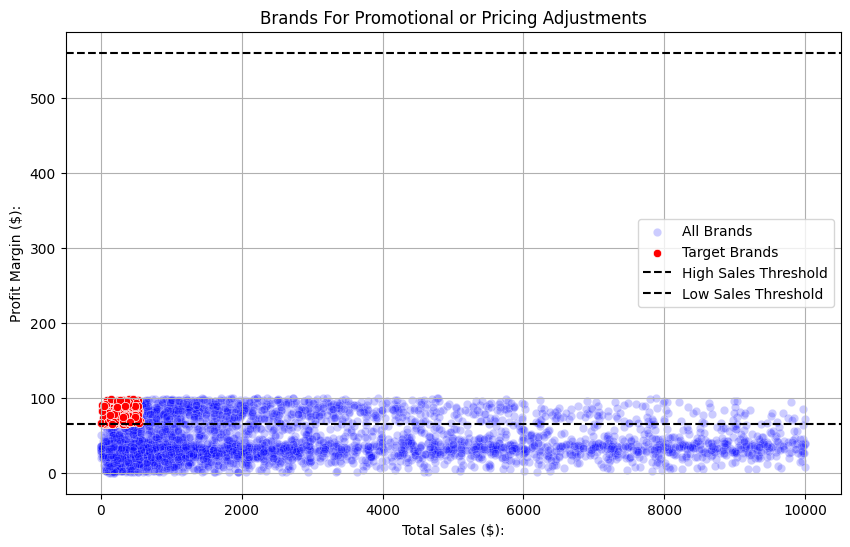

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(brand_perf,x='TotalSalesDollar',y='ProfitMargin',color='blue',label="All Brands",alpha=0.2)
sns.scatterplot(target_brands,x='TotalSalesDollar',y='ProfitMargin',color='red',label="Target Brands")

plt.axhline(high_sales_threshold,linestyle="--",color="black",label="High Sales Threshold")
plt.axhline(low_sales_threshold,linestyle="--",color="black",label="Low Sales Threshold")

plt.xlabel("Total Sales ($):")
plt.ylabel("Profit Margin ($):")
plt.title("Brands For Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which vendor and brand demonstrate highest sale performance?

In [18]:
# For Formatting Sales Values.
def format_Dollars(value):
    if value>= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [19]:
top_vendors=df.groupby("VendorName")["TotalSalesDollar"].sum().nlargest(10)
top_brands=df.groupby("description")["TotalSalesDollar"].sum().nlargest(10)
top_vendors.apply(lambda x:format_Dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollar, dtype: object

In [20]:
top_brands.apply(lambda x:format_Dollars(x))

description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollar, dtype: object

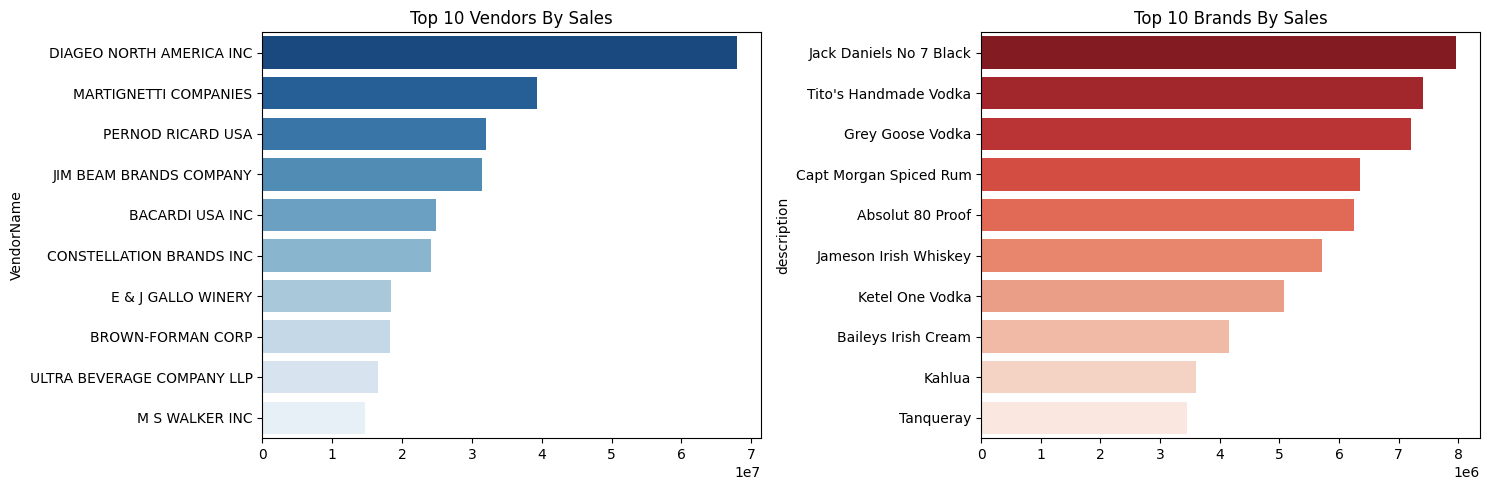

In [21]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
# For Top Vendors
sns.barplot(x=top_vendors.values,y=top_vendors.index,palette="Blues_r")
plt.title("Top 10 Vendors By Sales")
# For Top Brands
plt.subplot(1,2,2)
plt.title("Top 10 Brands By Sales")
sns.barplot(x=top_brands.values,y=top_brands.index.astype(str),palette="Reds_r")
plt.tight_layout()
plt.show()

Which Vendor contribute most to Total purchase dollars?

In [22]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'description', 'PurchasePrice',
       'volume', 'ActualPrice', 'Total_Qt', 'Total_Purchase', 'TotalSalesQt',
       'TotalSalesDollar', 'TotalSalesPrice', 'TotalExciseTax', 'Freight_Cost',
       'GrossProfit', 'ProfitMargin', 'StockTurnOver', 'SalesToPurchaseRatio'],
      dtype='object')

In [23]:
vendor_perf = df.groupby("VendorName").agg({
    "Total_Purchase":"sum",
    "GrossProfit":"sum",
    "TotalSalesDollar":"sum"
}).reset_index()

In [24]:
vendor_perf["PurchaseContribution %"]=(vendor_perf["Total_Purchase"]/vendor_perf["Total_Purchase"].sum())*100

In [25]:
vendor_perf = round(vendor_perf.sort_values("PurchaseContribution %",ascending=False),2)

In [26]:
# Formatting Sales Dollars
top_vendors = vendor_perf.head(10)
top_vendors["Total_Purchase"]=top_vendors["Total_Purchase"].apply(format_Dollars)
top_vendors["GrossProfit"]=top_vendors["GrossProfit"].apply(format_Dollars)
top_vendors["TotalSalesDollar"]=top_vendors["TotalSalesDollar"].apply(format_Dollars)
top_vendors

,VendorName,Total_Purchase,GrossProfit,TotalSalesDollar,PurchaseContribution %
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


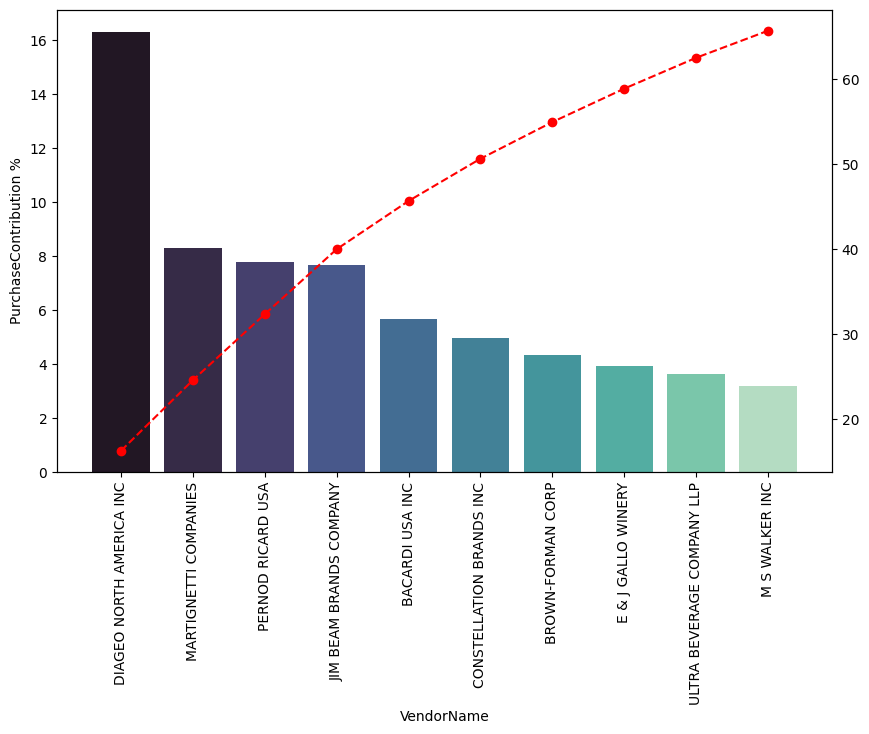

In [27]:
top_vendors["Cumulative_Contribution%"] = top_vendors["PurchaseContribution %"].cumsum()
fig,ax1 = plt.subplots(figsize=(10,6))
sns.barplot(x=top_vendors["VendorName"],y=top_vendors["PurchaseContribution %"],palette="mako",ax=ax1)
# Line plot
ax2 = ax1.twinx()
ax2.plot(top_vendors["VendorName"],top_vendors["Cumulative_Contribution%"],color="red",marker="o",linestyle="dashed",label="Cumulative Percentage")
ax1.set_xticklabels(labels=top_vendors["VendorName"],rotation=90)
plt.show()

<!-- How much total procurement is dependent on top vendors? -->

In [28]:
print(f'Total % Contribution of top 10 vendors:{round(top_vendors["PurchaseContribution %"].sum(),2)} %')

Total % Contribution of top 10 vendors:65.69 %


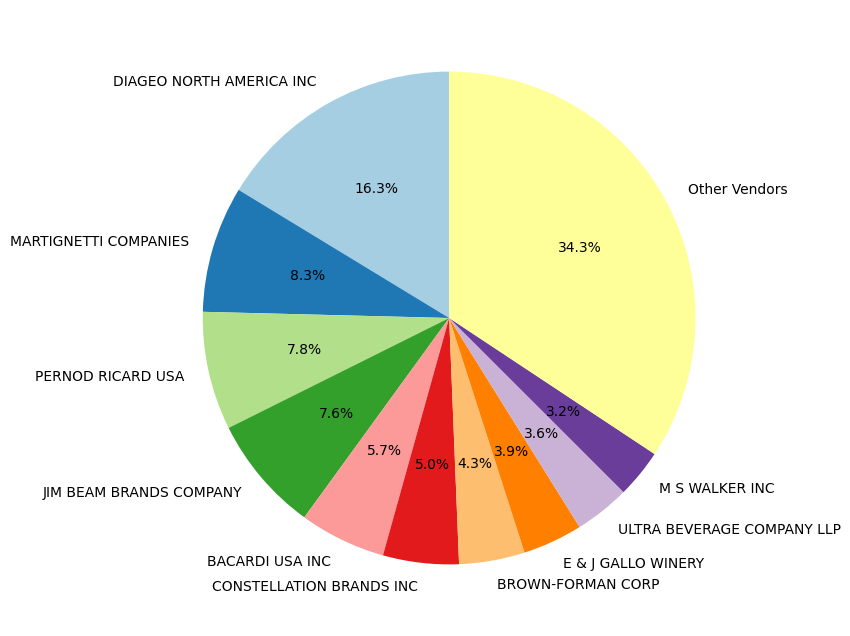

In [29]:
vendors = list(top_vendors["VendorName"].values)
purchase_contri = list(top_vendors["PurchaseContribution %"].values)
total_contri = sum(purchase_contri)
remaining_contri = 100-total_contri
vendors.append("Other Vendors")
purchase_contri.append(remaining_contri)

# Pie Chart
plt.figure(figsize=(8,8))
plt.pie(purchase_contri,autopct='%1.1f%%',startangle=90, labels=vendors,colors = plt.cm.Paired.colors)
plt.show()

Does purchasing in bulk reduce unit price and what is the optimal purchase volume for cost saving?

In [30]:
df['UnitPurchasePrice'] = df['Total_Purchase']/df['Total_Qt']
df

,VendorNumber,VendorName,Brand,description,PurchasePrice,volume,ActualPrice,Total_Qt,Total_Purchase,TotalSalesQt,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,Freight_Cost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,22.99,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,29.99,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,750.0,4.99,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,50.0,0.49,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,50.0,0.99,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,200.0,1.99,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [31]:
df["Ordersize"] = pd.qcut(df['Total_Qt'],q=3,labels=["Small","Medium","Large"]) #Dividing Qt into Quartiles
df

,VendorNumber,VendorName,Brand,description,PurchasePrice,volume,ActualPrice,Total_Qt,Total_Purchase,TotalSalesQt,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,Freight_Cost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio,UnitPurchasePrice,Ordersize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,22.99,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,29.99,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,750.0,4.99,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32,Small
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,50.0,0.49,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39,Small
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,50.0,0.99,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74,Small
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,200.0,1.99,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47,Small


In [32]:
df.groupby('Ordersize')[["UnitPurchasePrice"]].mean()

,UnitPurchasePrice
Ordersize,
Small,39.068186
Medium,15.486414
Large,10.777625


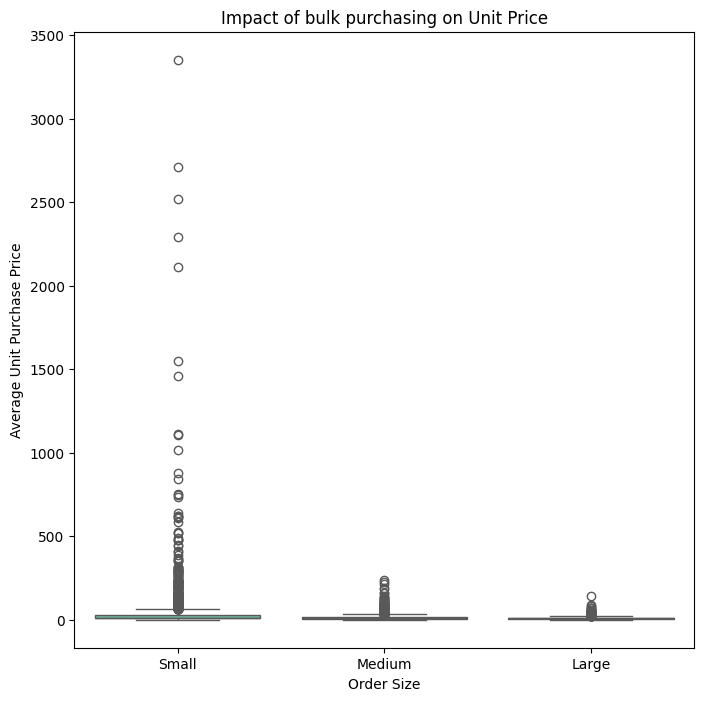

In [33]:
plt.figure(figsize=(8,8))
sns.boxplot(df,x="Ordersize",y="UnitPurchasePrice",palette="Set2")
plt.title("Impact of bulk purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.


# Which vendors have low inventory turnover, indicating excess stock and slow-moving products? 

In [34]:
df.groupby('VendorName')[['StockTurnOver']].mean().sort_values('StockTurnOver',ascending=True).head(10)

,StockTurnOver
VendorName,
TAMWORTH DISTILLING,0.797078
WALPOLE MTN VIEW WINERY,0.820548
SWEETWATER FARM,0.851047
BRONCO WINE COMPANY,0.866951
AMERICAN SPIRITS EXCHANGE,0.875000
SWEET BABY VINEYARD,0.876638
FULCHINO VINEYARD INC,0.879957
SOUTHERN GLAZERS W&S OF NE,0.883701
CENTEUR IMPORTS LLC,0.886976


In [35]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'description', 'PurchasePrice',
       'volume', 'ActualPrice', 'Total_Qt', 'Total_Purchase', 'TotalSalesQt',
       'TotalSalesDollar', 'TotalSalesPrice', 'TotalExciseTax', 'Freight_Cost',
       'GrossProfit', 'ProfitMargin', 'StockTurnOver', 'SalesToPurchaseRatio',
       'UnitPurchasePrice', 'Ordersize'],
      dtype='object')

# How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [36]:
df["UnsoldInventoryValue"]=(df["Total_Qt"]-df['TotalSalesQt']) * df['PurchasePrice']
print("Total Unsold Capital:",format_Dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 2.71M


In [37]:
#Aggregate Capital Locked per Vendor
inventory_value_per_vendor= df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()
#Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor[ 'UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_Dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


# What is the 95% confidence-interval for profit margins of top performing and low performing vendors?

In [38]:
top_threshold=df['TotalSalesDollar'].quantile(0.75)
low_threshold=df['TotalSalesDollar'].quantile(0.25)

In [39]:
top_vendors = df[df['TotalSalesDollar'] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df['TotalSalesDollar'] <= low_threshold]["ProfitMargin"].dropna()

In [40]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err=np.std (data, ddof=1)/np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf ((1+ confidence)/ 2,df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: ( 30.74,  31.61), Mean:  31.18
Low Vendors 95% CI: ( 40.50,  42.64), Mean: 41.57


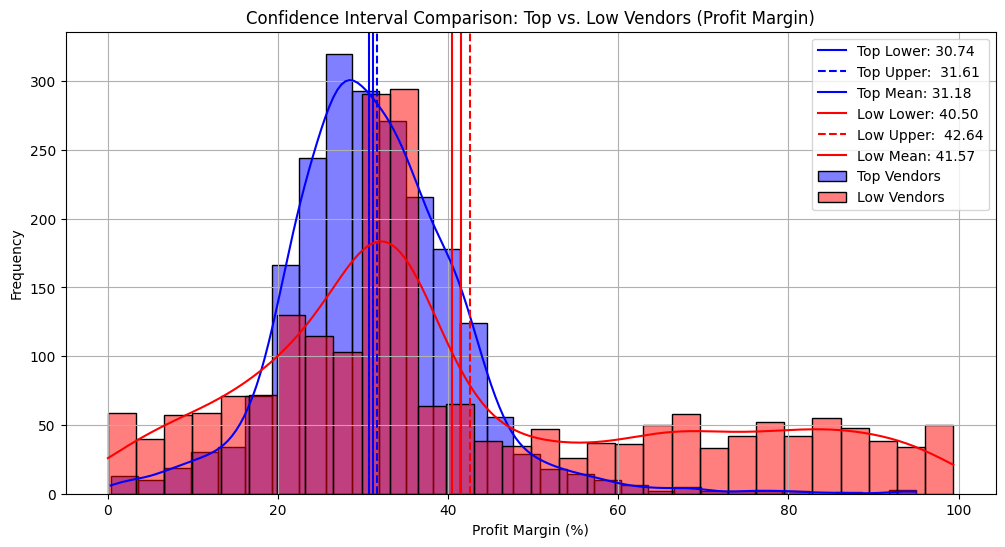

In [42]:
top_mean, top_lower, top_upper = confidence_interval (top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)
print (f"Top Vendors 95% CI: ({top_lower: .2f}, {top_upper: .2f}), Mean: {top_mean: .2f}")
print (f"Low Vendors 95% CI: ({low_lower: .2f}, {low_upper: .2f}), Mean: {low_mean:.2f}")
plt.figure(figsize=(12, 6))

#Top Vendors Plot
sns.histplot(top_vendors,kde=True,color="blue",bins=30,alpha=0.5,label="Top Vendors")
plt.axvline (top_lower, color="blue", linestyle="-", label=f"Top Lower: {top_lower:.2f}")
plt.axvline (top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper: .2f}")
plt.axvline (top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

#Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline (low_lower, color="red", linestyle="-", label=f"Low Lower: {low_lower:.2f}")
plt.axvline (low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper: .2f}")
plt.axvline (low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")
# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%). 
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies. 
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

# Is there a significant difference in profit margins between top-performing and low-performing vendors? 

Hypothesis:
- H0 (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors. 
- H1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [45]:
top_threshold=df['TotalSalesDollar'].quantile(0.75)
low_threshold=df['TotalSalesDollar'].quantile(0.25)

top_vendors = df[df['TotalSalesDollar'] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df['TotalSalesDollar'] <= low_threshold]["ProfitMargin"].dropna()

# Perform 2 Sample T-Test
t_stat,p_value= ttest_ind(top_vendors,low_vendors,equal_var=False)
print(f"T-Statistic:{t_stat:.4f}, P_Value:{p_value:.4f}")
if p_value<0.05:
    print("Reject H0:There is a significant difference in profit margins between top-performing and low-performing vendors.")
else:
    print("Fail To Reject H0:No significant difference in profit margins.")


T-Statistic:-17.6695, P_Value:0.0000
Reject H0:There is a significant difference in profit margins between top-performing and low-performing vendors.


In [47]:
vendor_summ = pd.read_sql('SELECT * FROM vendor_sales_summary' ,conn)
vendor_summ.to_csv('vendor_sales_summary.csv', index=False)